# Day 5 — Representation Learning & Embeddings

## Note 5.3 — Learning without labels: self-supervised and contrastive learning

### How to read this note

Run the cells from top to bottom, in order. Read each text cell before running the code cell under it.

Most code cells are short. Each one makes one thing or does one thing and prints what comes back. Look at it before moving on.

The **Questions to sit with** blocks are places to stop and think. Try to answer them in your own words.

Every number in the text of this note came from running this notebook on a CPU. On another machine a few numbers may differ slightly, because training involves many small calculations whose rounding can differ between processors. Times will differ more.

This note stands alone. Its data ships inside scikit-learn, so there is nothing to download.

### Learning goal and outcome

**Goal.** Understand how a network can learn a useful representation **without any labels**, and what contrastive learning is.

**Outcome.** By the end you can explain what a pretext task is, build two "views" of the same example, write the contrastive loss by hand, train a small encoder on it, and measure honestly what the training added, including when the answer is "less than you hoped".

### Objectives

By the end of this note you will be able to:

1. Explain why labels are often the bottleneck, and what *self-supervised* learning means.
2. Name three pretext tasks and say which famous models use each one.
3. Explain positive and negative pairs, and what contrastive learning pulls together and pushes apart.
4. Build data augmentations that make two views of one image.
5. Read a batch similarity matrix and say which cells are positives.
6. Write the contrastive loss (InfoNCE) from cross-entropy, with temperature.
7. Train an encoder with it, using the same training loop as Day 2.
8. Measure what the training added, with few labels, against a fair baseline and across seeds.
9. Connect what you built to how MiniLM and CLIP were trained.

### Datasets used

**scikit-learn digits.** 1,797 small images of handwritten digits (0 to 9), each 8 × 8 pixels in grey. It ships inside scikit-learn, so it loads instantly with no download.

Why this dataset: contrastive training normally needs huge datasets and big graphics cards. Tiny 8 × 8 images let us train a real contrastive encoder on a laptop CPU in under a minute, so you can watch every step. The digits also have labels, which we keep **locked away** during training and only use at the end, to score what the encoder learned.

### Table of contents

1. Labels are expensive
2. Pretext tasks: making the data teach itself
3. Positive and negative pairs
4. Meet the digits
5. Making two views of one digit
6. The encoder and its projection head
7. The similarity matrix of a batch
8. The contrastive loss, built by hand
9. Training without labels
10. Measuring what training added
11. Is it more than seed noise?
12. Before and after, as pictures
13. How MiniLM and CLIP used this same idea
14. What to take away

### Runtime budget

| Part | What happens | Time |
|---|---|---|
| Setup and Sections 1–8 | load digits, build views, loss by hand | under 1 minute |
| Section 9 | train one contrastive encoder (400 passes) | under 1 minute |
| Section 10 | score raw pixels, random encoder, trained encoder | under 1 minute |
| Section 11 | train two more encoders with other seeds | 1–2 minutes |
| Section 12 | two t-SNE maps | under 1 minute |
| Whole note | | about 4 minutes of running, plus reading |

### Environment setup

To install exactly the versions this note was built with, remove the `#` at the start of the `%pip` line, run it once, then restart the kernel.

In [1]:
# Remove the "#" on the next line to install the pinned versions, then restart the kernel.
# %pip install torch==2.14.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 matplotlib==3.10.8

In [2]:
import importlib.metadata as md

PINNED = {"torch": "2.14.0", "scikit-learn": "1.8.0", "numpy": "2.4.4",
          "pandas": "3.0.2", "matplotlib": "3.10.8"}

for package, wanted in PINNED.items():
    installed = md.version(package)
    status = "ok" if installed.split("+")[0] == wanted else "DIFFERENT"
    print(f"{package:14} pinned {wanted:8} installed {installed:12} {status}")

torch          pinned 2.14.0   installed 2.14.0+cpu   ok
scikit-learn   pinned 1.8.0    installed 1.8.0        ok
numpy          pinned 2.4.4    installed 2.4.4        ok
pandas         pinned 3.0.2    installed 3.0.2        ok
matplotlib     pinned 3.10.8   installed 3.10.8       ok


### Environment detection

This cell finds which hardware PyTorch could use (`cuda`, `mps` or `cpu`), and then the note uses the **CPU on purpose** so your numbers match the ones written here.

In [3]:
import torch

if torch.cuda.is_available():
    FOUND = "cuda"
elif torch.backends.mps.is_available():
    FOUND = "mps"
else:
    FOUND = "cpu"

DEVICE = "cpu"   # chosen on purpose, so numbers match this note
print("Best hardware found on this machine:", FOUND)
print("Hardware this note will use:        ", DEVICE)
print("CPU threads PyTorch can use:        ", torch.get_num_threads())

Best hardware found on this machine: cpu
Hardware this note will use:         cpu
CPU threads PyTorch can use:         1


In [4]:
import copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE

## 1. Labels are expensive

In note 5.1, a CNN pretrained on ImageNet gave us a much better representation of bean leaves. ImageNet has about 1.28 million photos, and **every one was labelled by a person**. That took years of paid work.

In note 5.2, MiniLM gave us excellent text embeddings. Its makers trained it on about **one billion pairs of sentences**. Nobody could pay people to label a billion sentence pairs.

So how did MiniLM learn? The answer is a family of methods called **self-supervised learning**: the training signal comes from the data itself, not from labels a person added. The data is arranged so that it asks itself a question, and the network learns by answering it.

This matters because unlabelled data is everywhere: every web page, every photo on a phone, every recording. Labelled data is rare and expensive. A method that learns from unlabelled data can learn from almost unlimited examples.

> **Questions to sit with**
>
> 1. Think of the data at a place you have worked. How much of it has clean labels? How much has none?
> 2. If you could train on all of it without labels, what would you want the representation to capture?

## 2. Pretext tasks: making the data teach itself

A **pretext task** is a made-up task that we do not actually care about, chosen because solving it forces the network to learn something useful. The labels for it come free, from the data itself.

Three famous pretext tasks:

```
 FILL IN THE BLANK            "my card was [____]"        → guess: "stolen"
 (masked word)                 the hidden word is the answer; no person needed to label it
                               used by BERT-style encoders (Day 6, Day 7)

 GUESS THE NEXT WORD          "my card was"               → guess: "stolen"
 (next token)                  the real next word is the answer
                               used by GPT-style models (Day 6, GenAI module)

 DO THESE TWO MATCH?          [photo A, cropped]  vs  [photo A, darker]   → yes
 (contrastive)                [photo A, cropped]  vs  [photo B]           → no
                               "same original or not" is the answer
                               used by CLIP, and by MiniLM's final training
```

In every case, the answer is already in the data. To fill in a blank well, a model must understand grammar and meaning. To tell which two photos came from the same original, it must understand what is in the photo, not just where the pixels are.

This note builds the third one, **contrastive learning**, because it is the one behind both encoders you used in 5.2 and will use in 5.4.

## 3. Positive and negative pairs

Contrastive learning works with pairs:

- A **positive pair** is two things that *should* get similar representations. Here: two different versions of the *same* digit image.
- A **negative pair** is two things that should get *different* representations. Here: versions of two *different* images.

The training goal is simple to say: **pull positive pairs together, push negative pairs apart**, measured with the cosine similarity from note 5.2.

Notice something important. "Different images" is not the same as "different digits". Two different images of a handwritten 7 count as a *negative* pair, because the method has no labels and cannot know they are both 7s. It only knows they are different images. We will see whether the encoder ends up grouping the 7s anyway.

<div align="center">

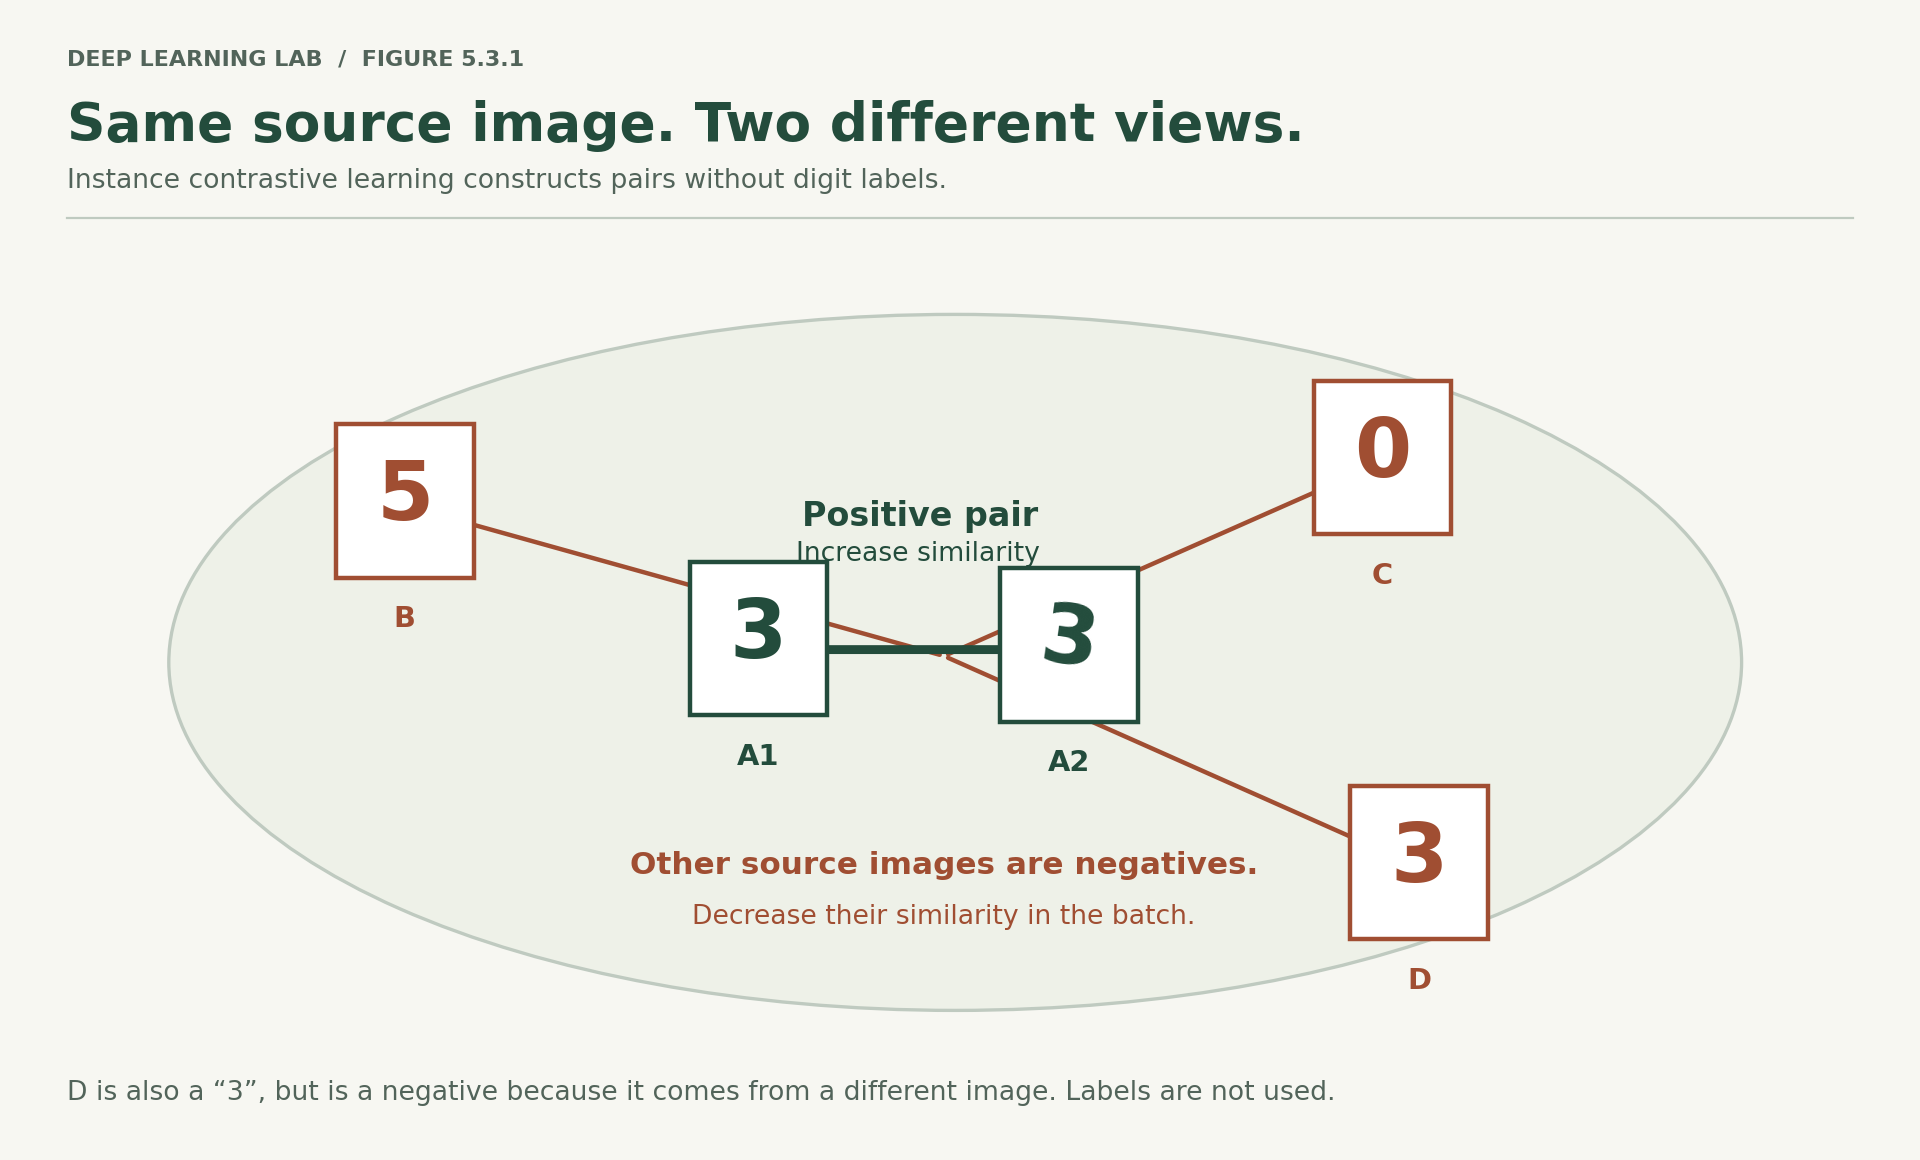

<p><b>Figure 5.3.1.</b> A1 and A2 are augmentations of one source image. B, C and D come from other images; D shows why false negatives can occur.</p>

</div>

## 4. Meet the digits

`load_digits(return_X_y=True)` returns the images as rows of 64 numbers (8 × 8, flattened) and their labels. Pixel values go from 0 to 16, so we divide by 16 to put them between 0 and 1.

In [5]:
X, y = load_digits(return_X_y=True)
X = X / 16.0
print("Images:", X.shape, " labels:", y.shape)
print("Pixel values from", X.min(), "to", X.max())
print("Images per digit:", np.bincount(y))

Images: (1797, 64)  labels: (1797,)
Pixel values from 0.0 to 1.0
Images per digit: [178 182 177 183 181 182 181 179 174 180]


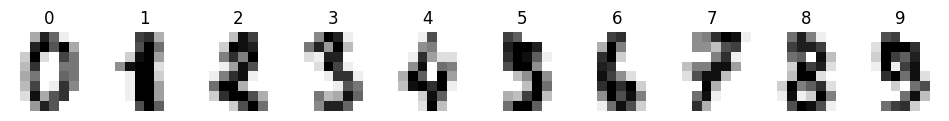

In [6]:
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for d in range(10):
    axes[d].imshow(X[y == d][0].reshape(8, 8), cmap="gray_r")
    axes[d].set_title(str(d))
    axes[d].axis("off")
plt.show()

`.reshape(8, 8)` turns a row of 64 numbers back into an 8 × 8 grid so it can be drawn. `cmap="gray_r"` draws high values dark, like ink on paper.

We split into a train part, which the encoder learns from, and a test part, used only for scoring at the end. `stratify=y` keeps the same share of each digit in both parts.

From here until Section 10, **the training code never touches `y_train`**. The labels exist, but they are locked away.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print("train:", X_train.shape, " test:", X_test.shape)

train: (1257, 64)  test: (540, 64)


## 5. Making two views of one digit

To make a positive pair, we take one image and change it in two different random ways. Each changed version is called a **view**, and making views is called **data augmentation**.

The changes must keep what matters (which digit it is) and change what should not matter (exact position, a few missing strokes, a little noise). Choosing these changes is the most important design decision in contrastive learning: **whatever the augmentations change, the encoder learns to ignore.**

We use three changes. Let us build each on one image first.

In [8]:
one = torch.tensor(X_train[0], dtype=torch.float32).view(1, 1, 8, 8)
print("Shape:", tuple(one.shape), "  (images, channels, height, width)")
print("This digit is a", y_train[0], "(we look at the label only to talk about it, never to train)")

Shape: (1, 1, 8, 8)   (images, channels, height, width)
This digit is a 6 (we look at the label only to talk about it, never to train)


**Change 1 — a random small shift.** `F.pad(x, (1, 1, 1, 1))` adds a border of zeros one pixel wide on the left, right, top and bottom, making the image 10 × 10. Cutting an 8 × 8 window out of that at a random position shifts the digit by up to one pixel in each direction.

In [9]:
padded = F.pad(one, (1, 1, 1, 1))
print("Padded shape:", tuple(padded.shape))
dy, dx = 0, 2                       # cut the window starting at row 0, column 2
shifted = padded[:, :, dy:dy + 8, dx:dx + 8]
print("Shifted shape:", tuple(shifted.shape))

Padded shape: (1, 1, 10, 10)
Shifted shape: (1, 1, 8, 8)


**Change 2 — random missing pixels.** `torch.rand_like(x)` makes random numbers between 0 and 1, one per pixel. Keeping only the pixels where that number is above 0.2 removes about 20% of the pixels.

**Change 3 — a little noise.** `torch.randn_like(x)` makes random numbers from a bell curve centred on 0. Multiplying by 0.1 makes them small, and adding them blurs the pixel values slightly.

In [10]:
torch.manual_seed(0)
keep = torch.rand_like(shifted) > 0.2
print("Fraction of pixels kept:", keep.float().mean().item())
dropped = shifted * keep
noisy = dropped + 0.1 * torch.randn_like(dropped)

Fraction of pixels kept: 0.78125


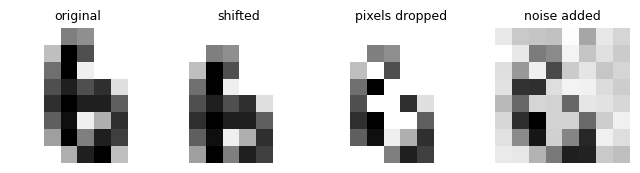

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(8, 2.2))
for ax, img, title in zip(axes, [one, shifted, dropped, noisy],
                          ["original", "shifted", "pixels dropped", "noise added"]):
    ax.imshow(img[0, 0], cmap="gray_r"); ax.set_title(title, fontsize=9); ax.axis("off")
plt.show()

Now we put the three changes into one function that works on a whole batch at once, picking a fresh random shift for every image. It returns each view flattened back to 64 numbers.

`torch.randint(0, 3, (B,))` draws `B` random whole numbers from 0, 1 or 2: the start row or column of each window.

In [12]:
def make_view(batch):
    B = batch.shape[0]
    x = F.pad(batch.view(B, 1, 8, 8), (1, 1, 1, 1))
    dy = torch.randint(0, 3, (B,))
    dx = torch.randint(0, 3, (B,))
    out = torch.stack([x[b, :, dy[b]:dy[b] + 8, dx[b]:dx[b] + 8] for b in range(B)])
    out = out * (torch.rand_like(out) > 0.2)
    out = out + 0.1 * torch.randn_like(out)
    return out.flatten(start_dim=1)

T_train = torch.tensor(X_train, dtype=torch.float32)
torch.manual_seed(1)
views = [make_view(T_train[:1]) for _ in range(5)]
print("One view:", tuple(views[0].shape))

One view: (1, 64)


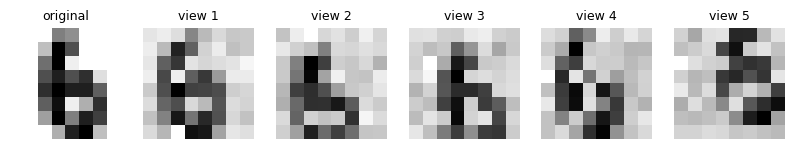

In [13]:
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
axes[0].imshow(X_train[0].reshape(8, 8), cmap="gray_r"); axes[0].set_title("original", fontsize=9)
for k, v in enumerate(views, start=1):
    axes[k].imshow(v.view(8, 8), cmap="gray_r"); axes[k].set_title(f"view {k}", fontsize=9)
for ax in axes: ax.axis("off")
plt.show()

Five different views of the same digit. Any two of them form a positive pair.

> **Questions to sit with**
>
> 1. Suppose we added "flip the image left to right" as an augmentation. What would the encoder learn to ignore? Why is that a problem for the digits 2 and 5?
> 2. For photos of bean leaves (note 5.1), which augmentations would be safe? Which would destroy the disease information?

## 6. The encoder and its projection head

The **encoder** is the network whose output we want as our representation. Here it is a small multilayer perceptron like Day 2's: 64 inputs → 256 → 64. Its 64 outputs are the representation.

During training we add one more small piece on top, called the **projection head**: 64 → 32. The contrastive loss is computed on the head's output, not the encoder's. After training, we **throw the head away** and keep only the encoder.

Why bother with a head? The loss pushes the network to ignore everything the augmentations change. The head gives it a place to throw that information away, so the encoder's own output can keep more general information. Researchers found this extra layer reliably gives a better representation.

```
 view ──▶ ENCODER (64 → 256 → 64) ──▶ representation ──▶ HEAD (64 → 32) ──▶ used by the loss
                                       └── kept after training        └── thrown away
```

In [14]:
def new_encoder_and_head(seed):
    torch.manual_seed(seed)
    encoder = nn.Sequential(nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 64))
    head = nn.Sequential(nn.ReLU(), nn.Linear(64, 32))
    return encoder, head

encoder, head = new_encoder_and_head(seed=0)
print(encoder)
print(head)
print("Encoder weights:", sum(p.numel() for p in encoder.parameters()))
print("Head weights:   ", sum(p.numel() for p in head.parameters()))

Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=64, bias=True)
)
Sequential(
  (0): ReLU()
  (1): Linear(in_features=64, out_features=32, bias=True)
)
Encoder weights: 33088
Head weights:    2080


Before training anything, we save an exact copy of the untrained encoder. `copy.deepcopy` makes a full, separate copy, so training `encoder` later does not change `random_encoder`.

This copy is our **fair baseline**. Same design, same starting weights, never trained. Anything the trained encoder does better than this copy, it learned from the contrastive training.

In [15]:
random_encoder = copy.deepcopy(encoder)
print("Same starting weights:", torch.equal(random_encoder[0].weight, encoder[0].weight))

Same starting weights: True


## 7. The similarity matrix of a batch

Contrastive learning compares every view in a batch with every other view. Let us see what that looks like for a tiny batch of 4 images.

1. Make two views of each image: `z1` (first views) and `z2` (second views).
2. Push them through encoder and head, and normalise each output to length 1, so dot products are cosine similarities (note 5.2). `F.normalize(z, dim=1)` divides each row by its length.
3. Stack them: rows 0 to 3 are first views, rows 4 to 7 are second views.
4. Multiply the stack by itself transposed to get every cosine similarity at once: an 8 × 8 matrix.

In [16]:
torch.manual_seed(2)
tiny = T_train[:4]
with torch.no_grad():
    z1 = F.normalize(head(encoder(make_view(tiny))), dim=1)
    z2 = F.normalize(head(encoder(make_view(tiny))), dim=1)
z = torch.cat([z1, z2])
sim = z @ z.T
print("Stacked views:", tuple(z.shape), "  similarity matrix:", tuple(sim.shape))
print(np.round(sim.numpy(), 2))

Stacked views: (8, 32)   similarity matrix: (8, 8)
[[1.   0.87 0.83 0.81 0.78 0.86 0.83 0.8 ]
 [0.87 1.   0.91 0.91 0.93 0.91 0.94 0.91]
 [0.83 0.91 1.   0.89 0.92 0.89 0.94 0.92]
 [0.81 0.91 0.89 1.   0.93 0.86 0.9  0.95]
 [0.78 0.93 0.92 0.93 1.   0.87 0.93 0.93]
 [0.86 0.91 0.89 0.86 0.87 1.   0.9  0.88]
 [0.83 0.94 0.94 0.9  0.93 0.9  1.   0.93]
 [0.8  0.91 0.92 0.95 0.93 0.88 0.93 1.  ]]


How to read this matrix:

- The **diagonal** (row 0 column 0, row 1 column 1, ...) is each view compared with itself, always 1.0. It tells us nothing and will be ignored.
- The **positives** are a view and its partner from the same image: row 0 with column 4, row 1 with column 5, and so on (and the mirror cells: row 4 with column 0, ...).
- **Everything else** is a negative: two views of different images.

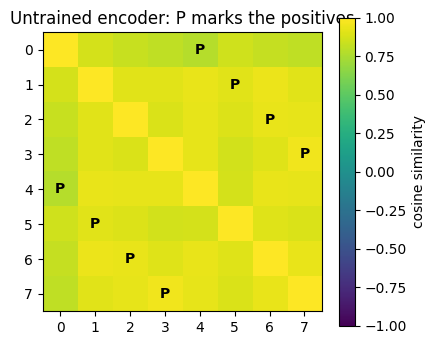

In [17]:
plt.figure(figsize=(4.5, 4))
plt.imshow(sim.numpy(), cmap="viridis", vmin=-1, vmax=1)
plt.colorbar(label="cosine similarity")
for i in range(4):
    for r, c in [(i, i + 4), (i + 4, i)]:
        plt.text(c, r, "P", ha="center", va="center", color="black", fontweight="bold")
plt.title("Untrained encoder: P marks the positives")
plt.xticks(range(8)); plt.yticks(range(8))
plt.show()

The untrained encoder gives **every** pair a high score, between about 0.78 and 0.95. Positives and negatives look the same: it squeezes all images into roughly the same direction, so nothing can be told apart. Training has to fix that.

<div align="center">

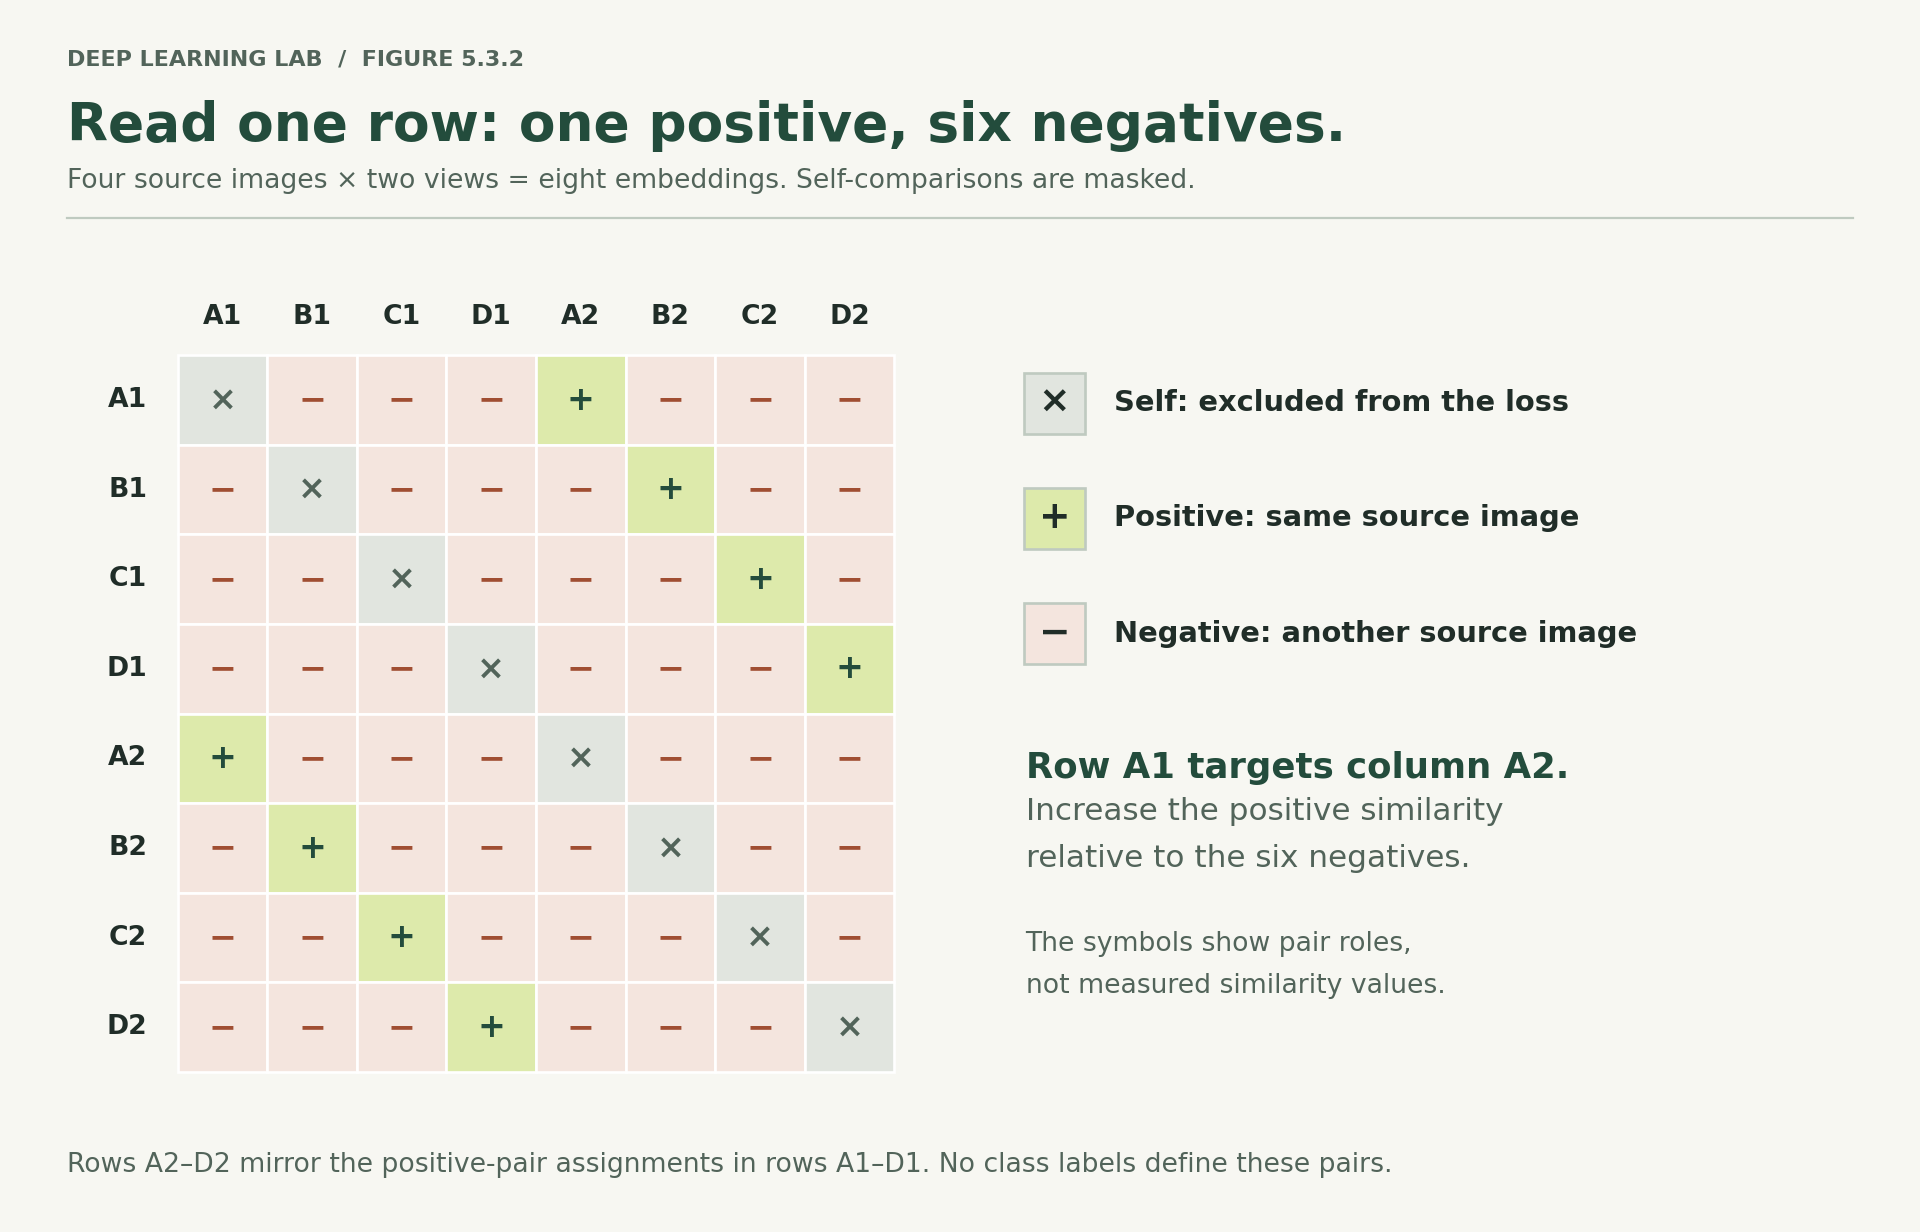

<p><b>Figure 5.3.2.</b> Pair assignments for the lesson’s eight-view batch. The diagonal is masked; offset diagonals are positives, and six remaining entries per row are negatives.</p>

</div>

## 8. The contrastive loss, built by hand

We want: in every row, the positive cell should be the **largest**. This is a classification problem in disguise. For row 0, the "correct class" is column 4, and the other columns are wrong classes.

You already know a loss for "pick the correct class out of many": **cross-entropy**, from your machine-learning work and Day 2. `F.cross_entropy(scores, targets)` takes a row of scores per example and the correct column for each. That is all the contrastive loss is: cross-entropy over the rows of the similarity matrix. It is called **InfoNCE** (*noise-contrastive estimation*), or the **NT-Xent** loss.

Two details before we write it:

- **Remove the diagonal.** A view always matches itself perfectly. We set the diagonal to a huge negative number, so it can never be chosen.
- **Temperature.** Cosine scores only go from −1 to 1, which is too narrow for cross-entropy to make strong choices. We divide the scores by a small number called the **temperature**, here 0.2. This stretches them out (dividing by 0.2 is multiplying by 5). A smaller temperature makes the loss focus harder on the negatives that look most like the positive.

In [18]:
temperature = 0.2
N = 4
logits = sim / temperature
logits.fill_diagonal_(-1e9)
targets = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)])
print("Correct column for each row:", targets.tolist())

Correct column for each row: [4, 5, 6, 7, 0, 1, 2, 3]


`fill_diagonal_` (the `_` at the end means it changes the tensor in place) writes −1e9 on the diagonal. The targets say: row 0's partner is column 4, row 1's is column 5, ..., row 4's is column 0, and so on.

Now the loss, and a check that it really is plain cross-entropy. For one row, cross-entropy is `−log(softmax(row)[correct column])`: turn the row into probabilities that add up to 1, then take minus the log of the probability given to the correct column.

In [19]:
loss = F.cross_entropy(logits, targets)
print(f"Contrastive loss for this tiny batch: {loss.item():.4f}")

row0 = torch.softmax(logits[0], dim=0)
print("Row 0 as probabilities:", np.round(row0.numpy(), 3))
print(f"-log(probability of row 0's partner) = {-torch.log(row0[4]).item():.4f}")

Contrastive loss for this tiny batch: 1.9408
Row 0 as probabilities: [0.    0.18  0.144 0.13  0.112 0.165 0.142 0.127]
-log(probability of row 0's partner) = 2.1869


The loss averages that number over all 8 rows.

What loss should an untrained encoder get? If it had no idea at all, each row would spread its probability evenly over the 7 other columns, so the partner would get 1/7, and the loss would be −log(1/7).

In [20]:
print(f"Loss for a 'no idea' encoder with 8 views: {np.log(7):.4f}")
print(f"Loss for a perfect encoder:                {0.0:.4f}")

Loss for a 'no idea' encoder with 8 views: 1.9459
Loss for a perfect encoder:                0.0000


Our untrained encoder scored **1.9408**, almost exactly the no-idea value of **1.9459**. In row 0, the partner (column 4) got a probability of only 0.112, actually *less* than an even share of 1/7. The untrained encoder really has no idea which views belong together, which is what we should expect.

Here is the same loss as a function for a batch of any size. It is exactly the steps above.

In [21]:
def contrastive_loss(z1, z2, temperature=0.2):
    N = z1.shape[0]
    z = torch.cat([F.normalize(z1, dim=1), F.normalize(z2, dim=1)])
    logits = (z @ z.T) / temperature
    logits.fill_diagonal_(-1e9)
    targets = torch.cat([torch.arange(N, 2 * N), torch.arange(0, N)])
    return F.cross_entropy(logits, targets)

With a batch of 256 images there are 512 views, so each row has 1 positive and 510 negatives. A no-idea encoder would score −log(1/511):

In [22]:
print(f"No-idea loss with 512 views: {np.log(511):.4f}")

No-idea loss with 512 views: 6.2364


## 9. Training without labels

This is the Day 2 training loop, line for line. The only differences: each batch becomes two views, and the loss is the contrastive loss. **There is no `y` anywhere in this loop.**

Settings: Adam with learning rate 0.001 (Day 3), batches of 256, and 400 **epochs** (full passes over the 1,257 training images). The images are tiny, so each epoch is fast.

`torch.randperm(n)` returns the numbers 0 to n − 1 in random order, so every epoch sees the images in a new order.

In [23]:
def train_contrastive(encoder, head, epochs=400, batch_size=256, seed=0):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(head.parameters()), lr=1e-3)
    history = []
    for epoch in range(epochs):
        order = torch.randperm(len(T_train))
        for start in range(0, len(T_train), batch_size):
            batch = T_train[order[start:start + batch_size]]
            optimizer.zero_grad()
            loss = contrastive_loss(head(encoder(make_view(batch))), head(encoder(make_view(batch))))
            loss.backward()
            optimizer.step()
        history.append(loss.item())
    return history

`history` keeps the loss of the last batch in each epoch, so we can draw the learning curve (Day 3) afterwards.

In [24]:
start = time.perf_counter()
history = train_contrastive(encoder, head, seed=0)
print(f"Trained 400 epochs in {time.perf_counter() - start:.1f} s")
print(f"Loss: first epoch {history[0]:.4f}, last epoch {history[-1]:.4f}")

Trained 400 epochs in 48.2 s
Loss: first epoch 6.0456, last epoch 3.7332


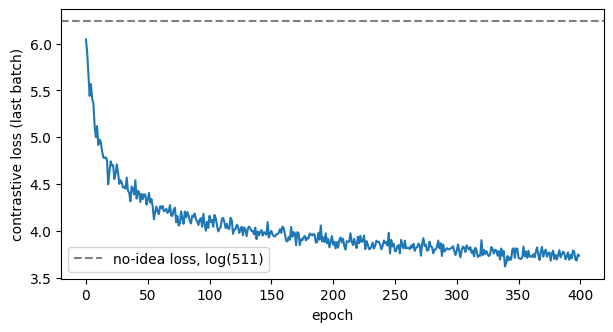

In [25]:
plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.axhline(np.log(511), linestyle="--", color="grey", label="no-idea loss, log(511)")
plt.xlabel("epoch"); plt.ylabel("contrastive loss (last batch)")
plt.legend(); plt.show()

The loss starts at **6.0456**, just under the no-idea value of 6.2364, and falls to **3.7332**. It is still far from zero, and it never will be: some negatives are views of other images of the *same* digit, which look genuinely alike, and the encoder is being asked to push them apart anyway. The curve is noisy because each point is a single batch with fresh random views, the "noisy loss" pattern from Day 3.

Let us look at the tiny batch's similarity matrix again, with the trained encoder. We use the same seed as in Section 7, so the views are made the same way.

In [26]:
torch.manual_seed(2)
with torch.no_grad():
    z1 = F.normalize(head(encoder(make_view(tiny))), dim=1)
    z2 = F.normalize(head(encoder(make_view(tiny))), dim=1)
sim_after = torch.cat([z1, z2]) @ torch.cat([z1, z2]).T
print(np.round(sim_after.numpy(), 2))

[[ 1.   -0.16 -0.22 -0.14  0.91 -0.2   0.11 -0.25]
 [-0.16  1.    0.26 -0.43 -0.23  0.77  0.11 -0.23]
 [-0.22  0.26  1.   -0.14 -0.01  0.3   0.73 -0.01]
 [-0.14 -0.43 -0.14  1.   -0.18 -0.41  0.15  0.84]
 [ 0.91 -0.23 -0.01 -0.18  1.   -0.25  0.19 -0.17]
 [-0.2   0.77  0.3  -0.41 -0.25  1.   -0.04 -0.26]
 [ 0.11  0.11  0.73  0.15  0.19 -0.04  1.    0.2 ]
 [-0.25 -0.23 -0.01  0.84 -0.17 -0.26  0.2   1.  ]]


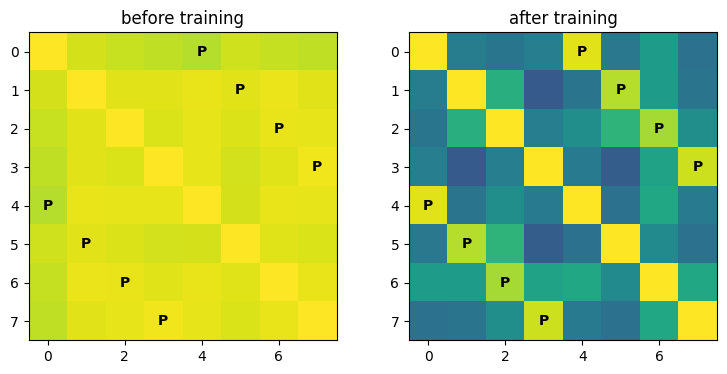

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, m, title in [(axes[0], sim, "before training"), (axes[1], sim_after, "after training")]:
    ax.imshow(m.numpy(), cmap="viridis", vmin=-1, vmax=1)
    for i in range(4):
        for r, c in [(i, i + 4), (i + 4, i)]:
            ax.text(c, r, "P", ha="center", va="center", color="black", fontweight="bold")
    ax.set_title(title)
plt.show()

After training, the positives score **0.91, 0.77, 0.73 and 0.84**, and most negatives have dropped to around zero or below. In every row, the brightest cell (other than the diagonal) is now the positive. The encoder learned to recognise "same image, changed" without ever seeing a label.

## 10. Measuring what training added

Now we unlock the labels, but only for scoring.

The question we ask is the one that matters in practice: **if you only had a few labelled examples, how good a classifier could you build on top of this representation?** We give a classifier only 1, 5 or 10 labelled training images per digit, and test it on the full test set.

We compare three representations:

- **raw pixels**: the 64 numbers themselves;
- **random encoder**: the untrained copy from Section 6 (same design, same starting weights);
- **trained encoder**: after contrastive training (head thrown away).

And two ways of using the few labels: logistic regression, and 1-nearest-neighbour (note 5.2).

First, a function that picks the first `n` training images of each digit. Picking the *first* ones, not random ones, means every representation is scored on exactly the same few labelled images.

In [28]:
def few_labels(n):
    return np.concatenate([np.where(y_train == d)[0][:n] for d in range(10)])

print("With 1 label per digit, we use training images:", few_labels(1))

With 1 label per digit, we use training images: [ 9 11  4  3  1 16  0  5 18 34]


In [29]:
def represent(network, X):
    with torch.no_grad():
        return network(torch.tensor(X, dtype=torch.float32)).numpy()

def score(train_features, test_features, n):
    idx = few_labels(n)
    lr = LogisticRegression(max_iter=3000).fit(train_features[idx], y_train[idx])
    nn1 = KNeighborsClassifier(n_neighbors=1).fit(train_features[idx], y_train[idx])
    return lr.score(test_features, y_test), nn1.score(test_features, y_test)

In [30]:
representations = {
    "raw pixels": (X_train, X_test),
    "random encoder": (represent(random_encoder, X_train), represent(random_encoder, X_test)),
    "trained encoder": (represent(encoder, X_train), represent(encoder, X_test)),
}
rows = []
for name, (A, B) in representations.items():
    for n in [1, 5, 10]:
        lr_acc, nn_acc = score(A, B, n)
        rows.append({"representation": name, "labels per digit": n,
                     "logistic regression": round(lr_acc, 4), "1-NN": round(nn_acc, 4)})
results = pd.DataFrame(rows)
results

,representation,labels per digit,logistic regression,1-NN
0,raw pixels,1,0.5667,0.5648
1,raw pixels,5,0.8648,0.8611
2,raw pixels,10,0.9056,0.9111
3,random encoder,1,0.4741,0.4574
4,random encoder,5,0.7204,0.7889
5,random encoder,10,0.8241,0.8741
6,trained encoder,1,0.6093,0.6000
7,trained encoder,5,0.8370,0.8074
8,trained encoder,10,0.9037,0.8611


Read the table in two comparisons, because they answer two different questions.

**Trained encoder against random encoder: did contrastive training add anything?** Yes, clearly, at every number of labels. With logistic regression: **0.6093** against **0.4741** with 1 label per digit, **0.8370** against **0.7204** with 5, and **0.9037** against **0.8241** with 10. Same design, same starting weights; the only difference is training *without labels*.

**Trained encoder against raw pixels: is the learned representation better than doing nothing?** Only with 1 label per digit (**0.6093** against **0.5667**). With 5 labels, raw pixels win (**0.8648** against **0.8370**). With 10, they are about level (**0.9056** against **0.9037**). With 1-NN, raw pixels do better at 5 and 10 labels.

This is the result the plan for this note predicted might happen, and it did. Tiny 8 × 8 digits, already centred and cleaned, are a *good* representation as they are. Our small encoder learned a lot compared with where it started, but not enough to beat pixels that were already good. Section 11 checks whether this is luck; Section 13 explains why the big encoders are different.

> **Questions to sit with**
>
> 1. Why is the random encoder the fair baseline for "what did contrastive training add?", and raw pixels a different question ("is this better than doing nothing?")?
> 2. Raw 8 × 8 digit pixels are already clean and centred. Would you expect raw pixels to be as strong on 500 × 500 field photos of beans? Look back at note 5.1.

## 11. Is it more than seed noise?

On Day 4 (note 4.2) we learned that a single training run can be lucky or unlucky. Let us train two more encoders from different random starting points (seeds 1 and 2), each with its own untrained copy, and look at the spread. This is the same code as Sections 6 and 9, in a loop.

In [31]:
start = time.perf_counter()
per_seed = []
for seed in [0, 1, 2]:
    if seed == 0:
        enc, rand = encoder, random_encoder           # already trained above
    else:
        enc, hd = new_encoder_and_head(seed)
        rand = copy.deepcopy(enc)
        train_contrastive(enc, hd, seed=seed)
    for label, net in [("random encoder", rand), ("trained encoder", enc)]:
        A, B = represent(net, X_train), represent(net, X_test)
        for n in [1, 5, 10]:
            per_seed.append({"seed": seed, "representation": label, "labels per digit": n,
                             "logistic regression": score(A, B, n)[0]})
print(f"Done in {time.perf_counter() - start:.1f} s")

Done in 94.4 s


`groupby(...).agg(["mean", "std"])` groups the rows by representation and number of labels, then gives the average and the standard deviation (the spread) across the three seeds.

In [32]:
spread = (pd.DataFrame(per_seed)
          .groupby(["representation", "labels per digit"])["logistic regression"]
          .agg(["mean", "std"]).round(4))
spread

mean     std
representation  labels per digit                
random encoder  1                 0.4957  0.0270
                5                 0.7463  0.0251
                10                0.8235  0.0195
trained encoder 1                 0.5975  0.0172
                5                 0.8327  0.0047
                10                0.8981  0.0067

In [33]:
raw_lr = {n: round(score(X_train, X_test, n)[0], 4) for n in [1, 5, 10]}
print("Raw pixels, logistic regression (no seed involved):", raw_lr)

Raw pixels, logistic regression (no seed involved): {1: 0.5667, 5: 0.8648, 10: 0.9056}


Across three seeds, the trained encoder averages **0.5975, 0.8327 and 0.8981** with 1, 5 and 10 labels, with spreads (standard deviations) of **0.0172, 0.0047 and 0.0067**. The random encoder averages **0.4957, 0.7463 and 0.8235**.

So:

- The gain over the random encoder is roughly **0.10, 0.09 and 0.07**: many times larger than the seed spread. It is real.
- Against raw pixels (**0.5667, 0.8648, 0.9056**), the trained encoder is ahead with 1 label by about 0.03, behind with 5 labels by about 0.03, and slightly behind with 10. The 5-label gap (0.0321) is nearly seven times the seed spread (0.0047), so raw pixels really are better there.

The honest summary of this experiment: **contrastive learning taught the encoder a great deal from no labels, but on data this simple, "a great deal" only catches up with raw pixels.**

## 12. Before and after, as pictures

As in note 5.2, a t-SNE map squashes the 64-number representations into 2 dimensions. The labels are used **only to colour the dots**: t-SNE never sees them, and neither did the training.

In [34]:
start = time.perf_counter()
before_map = TSNE(n_components=2, random_state=0).fit_transform(represent(random_encoder, X_test))
after_map = TSNE(n_components=2, random_state=0).fit_transform(represent(encoder, X_test))
print(f"Two t-SNE maps in {time.perf_counter() - start:.1f} s")

Two t-SNE maps in 5.9 s


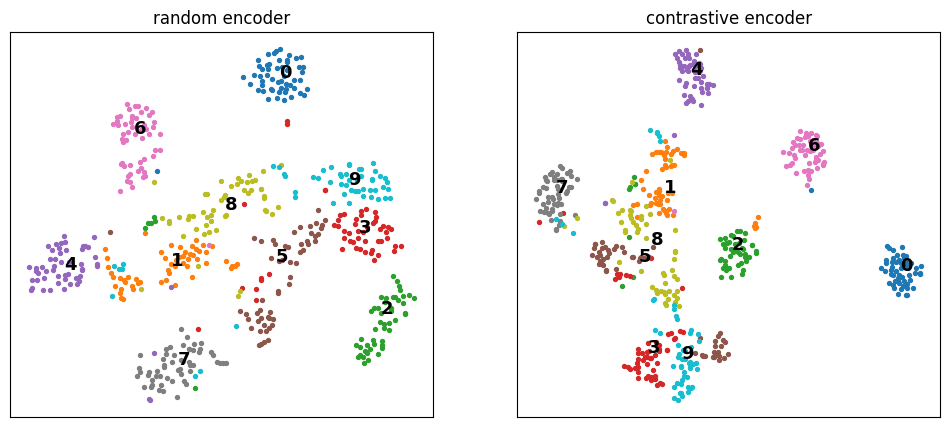

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pts, title in [(axes[0], before_map, "random encoder"), (axes[1], after_map, "contrastive encoder")]:
    for d in range(10):
        m = y_test == d
        ax.scatter(pts[m, 0], pts[m, 1], s=8, label=str(d))
        ax.text(*np.median(pts[m], axis=0), str(d), fontsize=13, fontweight="bold")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.show()

Here the picture can fool you. The random encoder's map already shows clear groups, because a random layer is just a random mixing of raw pixels, and raw pixels already separate many digits well (Section 10).

The contrastive map has tighter groups for some digits (0, 2, 4, 6, 7), but mixes others: 3 sits with 9, and 1, 5 and 8 overlap. Looking at the two maps alone, you could not say which representation is better, and you might pick the wrong one.

Remember the warning from note 5.2: a t-SNE picture is a flattened shadow. The numbers in Sections 10 and 11 are the evidence; the picture only helps you see them.

## 13. How MiniLM and CLIP used this same idea

What you built is a small version of a method called **SimCLR**. The same recipe, at enormous scale, made the encoders you use in notes 5.2 and 5.4.

**MiniLM (note 5.2).** Its makers started from a small Transformer called MiniLM, which had been made by compressing a larger model that learned language with the fill-in-the-blank pretext task. They then trained it further with **the same kind of contrastive loss you wrote in Section 8** (cross-entropy over a batch similarity matrix, with a temperature), on about one billion pairs of sentences. The positive pairs were not augmentations but pairs that occur naturally on the web: a question and its answer, a post title and its body, two ways of asking the same question. Nobody labelled them; they came paired already. Every other sentence in the batch served as a negative.

**CLIP (note 5.4).** Same loss, but the two views are **a photo and its caption**. The positive pair is a photo and the text that was posted with it; every other caption in the batch is a negative. Trained on about 400 million photo-caption pairs collected from the web, this puts photos and sentences into one shared space, which you will use in the next note.

```
 THIS NOTE          view 1 of a digit       ⟷  view 2 of the same digit        1,257 images
 MiniLM             a question              ⟷  its answer                      ~1 billion pairs
 CLIP               a photo                 ⟷  its caption                     ~400 million pairs
                    └───────────── same contrastive loss, same batch matrix ────────────┘
```

Why does the same idea work so well there and only modestly here? Three reasons, all about scale:

- **Raw inputs that are poor.** Raw 8 × 8 digit pixels are already a decent representation. Raw sentences (letters) and raw photos (note 5.1's 0.5938) are not, so there is far more for learning to add.
- **Far more data.** 1,257 images against hundreds of millions of pairs. Contrastive learning gets better with more data and with more negatives per batch; ours had 510, CLIP's had tens of thousands.
- **Bigger encoders.** 33,088 weights here, against 22.7 million in MiniLM and over 150 million in CLIP.

So the lesson of this note is the method, and an honest sense of when it pays: on large, raw, unlabelled data.

## 14. What to take away

- **Self-supervised learning** gets its training signal from the data itself, so it can use unlimited unlabelled data.
- A **pretext task** is a made-up task whose answer is already in the data: fill in the blank (BERT), guess the next word (GPT), do these two match (contrastive).
- **Contrastive learning** pulls positive pairs together and pushes negative pairs apart. The **augmentations** decide what the encoder learns to ignore.
- The **contrastive loss (InfoNCE)** is just cross-entropy over the rows of the batch similarity matrix, with the diagonal removed and a **temperature** to stretch the scores.
- A **projection head** is used during training and thrown away after.
- Measured honestly, with a fair baseline and three seeds, our tiny encoder learned something real from no labels. It did *not* clearly beat raw pixels, because 8 × 8 digits are already a good representation as they are. Self-supervision pays off at a scale and on raw inputs where raw values are poor, which is exactly what MiniLM and CLIP show.

### Next: note 5.4 — CLIP: one space for images and text

You now know the loss that trained CLIP. In note 5.4 you will load CLIP itself, put photos and sentences into the same space, classify photos using only the *names* of their classes, search photos with sentences, and find the place where it breaks: the bean leaves from note 5.1.